# VNA Circle Fit Analysis - CSV Version

This notebook performs circle fitting on VNA data exported as a **CSV file
from an Anritsu VNA** (e.g. `OUT2.csv`) to extract Q factors.

**Requirements:**
- qkit package: `pip install qkit`
- A `.csv` file exported by the VNA, with `!`-prefixed comment/metadata
  lines followed by a header row starting with `PNT,...`

**About the data format:** this export contains a `PNT` index column plus
one `FREQx.GHZ` / magnitude / `PHASEx.DEG` column group per trace (e.g.
`FREQ1.GHZ, LOGMAG1, PHASE1.DEG` for trace 1, `FREQ2.GHZ, LINMAG2,
PHASE2.DEG` for trace 2). The metadata comments at the top of the file
say which S-parameter and port each trace corresponds to.

**Which trace to fit:** for `OUT2.csv`, both traces are **S21** on PORT1.
Trace 1 (log-mag/phase) shows a clean notch dip (~-75 dB at 7.647 GHz vs.
a ~-63 dB baseline) \u2014 a standard transmission resonance \u2014 so this
notebook defaults to **trace 1** with `notch_port()`. Change `trace` /
`fit_type` below if your file's resonance is on a different trace or is a
reflection (S11/S22) measurement instead.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# # Compatibility shim: some qkit versions still use the deprecated np.complex/
# # np.float/np.int aliases, which were removed in recent NumPy releases.
# # This restores them so qkit's circle-fit code keeps working.
# if not hasattr(np, 'complex'):
#     np.complex = complex
# if not hasattr(np, 'float'):
#     np.float = float
# if not hasattr(np, 'int'):
#     np.int = int

# # Try importing qkit
# try:
#     from qkit.analysis.circle_fit.circle_fit_classic.circuit import notch_port, reflection_port
#     print("\u2713 qkit loaded successfully")
# except ImportError:
#     print("\u2717 qkit not found. Install with: pip install qkit")
#     raise

# # Set plotting style
plt.style.use('default')

## 1. Load VNA Data from CSV

**Important:** Modify the parameters below to match your data file:
- `csv_filename`: Your CSV file name
- `trace`: Which trace's columns to use (`1`, `2`, ...) \u2014 check the
  `!PARAMETER:` / `!PORT:` comment lines at the top of the file to see
  what each trace measures
- `fit_type`: `'notch'` for S21/S12 (transmission dip) or `'reflection'`
  for S11/S22 (resonance dip approaching the unit circle)

In [3]:
# ============================================================================
# CONFIGURATION - MODIFY THESE PARAMETERS FOR YOUR DATA
# ============================================================================

# Your CSV file name (put it in the same directory as this notebook)
csv_filename = "OUT2.csv"

# Which trace to fit, and which qkit port model to use.
# For OUT2.csv, trace 1 (S21, log-mag/phase) shows the notch dip.
trace = 1              # 1, 2, 3, ... matches the FREQx/...x column suffix
fit_type = "notch"     # 'notch' (S21/S12) or 'reflection' (S11/S22)

# ============================================================================
# LOAD DATA
# ============================================================================


def load_anritsu_csv(filename, trace=1):
    '''Parse an Anritsu VNA CSV export: skips the leading !-comment/metadata
    block, then reads the PNT,FREQx.GHZ,... data table. Reconstructs a
    complex trace from whichever column pair is present for the requested
    trace number (LOGMAG+PHASE in dB/deg, LINMAG+PHASE in linear/deg, or
    REAL+IMAG directly).'''
    with open(filename, "r") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("PNT"):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find a 'PNT,...' header row in {filename}")

    df = pd.read_csv(filename, skiprows=header_idx)
    df.columns = [c.strip() for c in df.columns]

    freq_col = f"FREQ{trace}.GHZ"
    if freq_col not in df.columns:
        raise ValueError(
            f"Column '{freq_col}' not found for trace={trace}. "
            f"Available columns: {list(df.columns)}"
        )
    freq_hz = df[freq_col].values * 1e9

    logmag_col = f"LOGMAG{trace}"
    linmag_col = f"LINMAG{trace}"
    phase_col = f"PHASE{trace}.DEG"
    real_col = f"REAL{trace}"
    imag_col = f"IMAG{trace}"

    if logmag_col in df.columns and phase_col in df.columns:
        amp_db = df[logmag_col].values
        phase_deg = df[phase_col].values
        s_complex = 10 ** (amp_db / 20) * np.exp(1j * np.deg2rad(phase_deg))
        kind = "logmag_phase"
    elif real_col in df.columns and imag_col in df.columns:
        s_complex = df[real_col].values + 1j * df[imag_col].values
        amp_db = 20 * np.log10(np.abs(s_complex))
        phase_deg = np.angle(s_complex, deg=True)
        kind = "real_imag"
    elif linmag_col in df.columns and phase_col in df.columns:
        mag = df[linmag_col].values
        phase_deg = df[phase_col].values
        # mag * exp(j*phase) reconstructs the correct complex value even if
        # 'mag' carries a sign (some exports fold a +/-180 deg ambiguity
        # into this column) - the math self-corrects, so no special-casing
        # is needed, just a heads-up if it happens.
        if (mag < 0).any():
            print(f"  Note: '{linmag_col}' contains negative values; treated "
                  f"as a signed linear amplitude (still reconstructs correctly).")
        s_complex = mag * np.exp(1j * np.deg2rad(phase_deg))
        amp_db = 20 * np.log10(np.abs(s_complex))
        kind = "linmag_phase"
    else:
        raise ValueError(
            f"No recognized column pair for trace={trace}. "
            f"Available columns: {list(df.columns)}"
        )

    return freq_hz, s_complex, amp_db, phase_deg, kind


try:
    freq_hz, s21_complex, amplitude_db, phase_deg, data_kind = load_anritsu_csv(csv_filename, trace=trace)
    print(f"\u2713 Successfully parsed: {csv_filename}")
    print(f"  Trace {trace} column type: {data_kind}")
    print(f"  Number of frequency points: {len(freq_hz)}")
    print(f"  Frequency range: {freq_hz.min()/1e9:.6f} - {freq_hz.max()/1e9:.6f} GHz")
except Exception as e:
    print(f"\u2717 Failed to load {csv_filename}: {e}")
    raise

frequency = freq_hz  # kept as 'frequency' / 's21_complex' so the rest of
                      # the notebook works unchanged

print(f"\n\u2713 Using trace {trace} for fitting (fit_type = '{fit_type}')")
print(f"  Amplitude range: {amplitude_db.min():.2f} to {amplitude_db.max():.2f} dB")
print(f"  Phase range: {phase_deg.min():.2f} to {phase_deg.max():.2f} degrees")

✓ Successfully parsed: OUT2.csv
  Trace 1 column type: logmag_phase
  Number of frequency points: 4001
  Frequency range: 7.631755 - 7.661755 GHz

✓ Using trace 1 for fitting (fit_type = 'notch')
  Amplitude range: -75.48 to -62.91 dB
  Phase range: 86.94 to 174.39 degrees


## 2. Verify Complex Data

The amplitude/phase columns have already been combined into a complex trace above.

In [4]:
print("\u2713 Complex data ready (reconstructed from the CSV amplitude/phase columns)")
print(f"  Real part range: {s21_complex.real.min():.6f} to {s21_complex.real.max():.6f}")
print(f"  Imag part range: {s21_complex.imag.min():.6f} to {s21_complex.imag.max():.6f}")

✓ Complex data ready (reconstructed from the CSV amplitude/phase columns)
  Real part range: -0.000621 to 0.000037
  Imag part range: 0.000059 to 0.000715


## 3. Plot Raw Data

Visualize the loaded data before fitting.

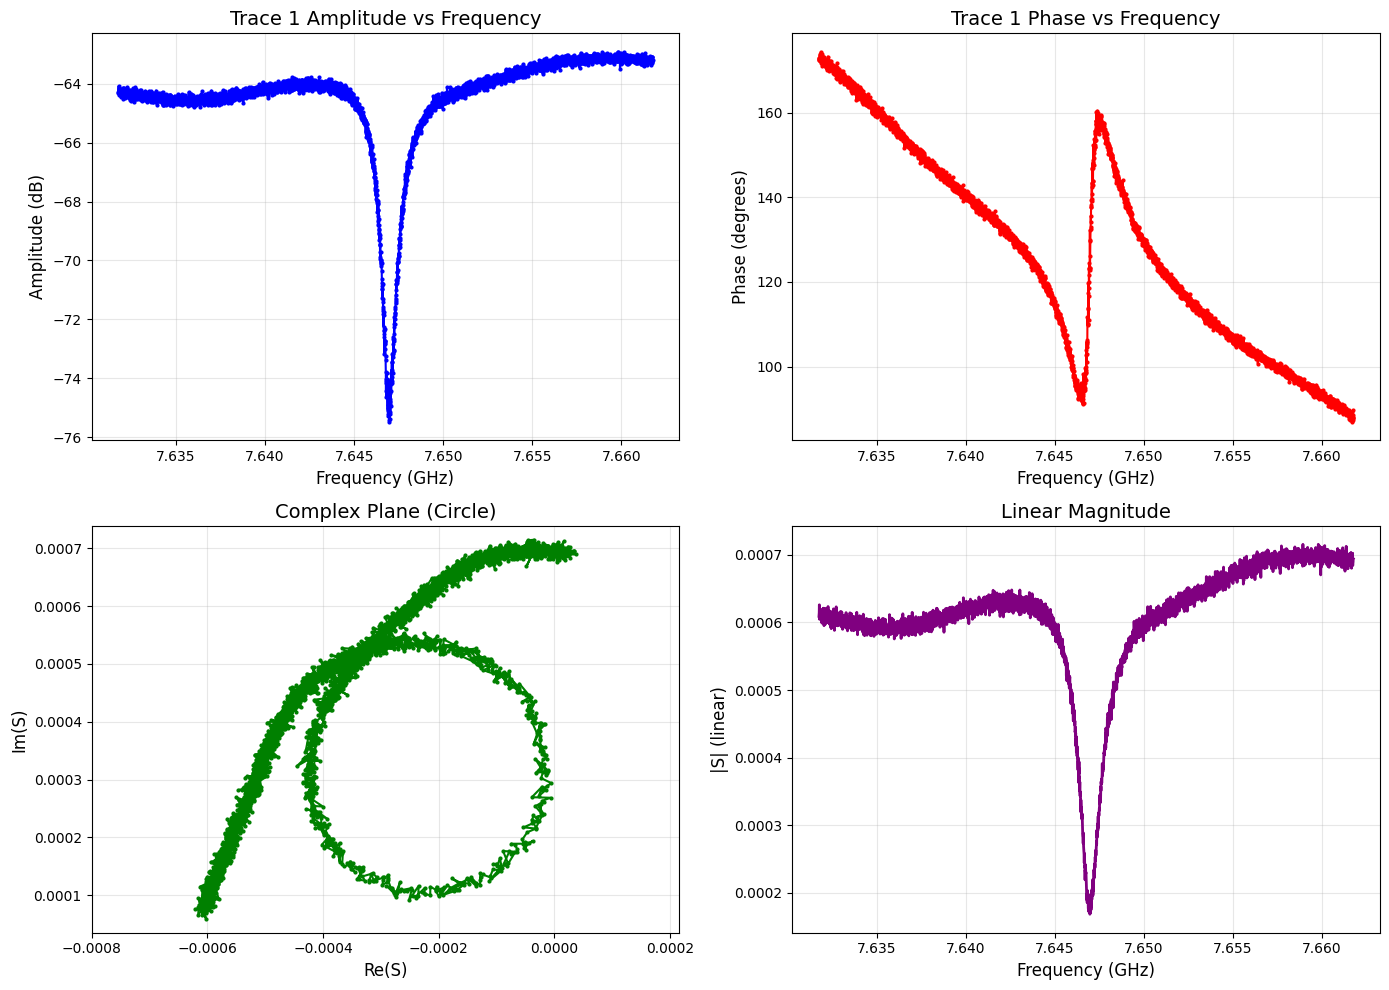

✓ Raw data plotted successfully


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amplitude vs Frequency
axes[0, 0].plot(frequency/1e9, amplitude_db, 'b.-', markersize=4)
axes[0, 0].set_xlabel('Frequency (GHz)', fontsize=12)
axes[0, 0].set_ylabel('Amplitude (dB)', fontsize=12)
axes[0, 0].set_title(f'Trace {trace} Amplitude vs Frequency', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# Phase vs Frequency
axes[0, 1].plot(frequency/1e9, phase_deg, 'r.-', markersize=4)
axes[0, 1].set_xlabel('Frequency (GHz)', fontsize=12)
axes[0, 1].set_ylabel('Phase (degrees)', fontsize=12)
axes[0, 1].set_title(f'Trace {trace} Phase vs Frequency', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Complex plane
axes[1, 0].plot(s21_complex.real, s21_complex.imag, 'g.-', markersize=4)
axes[1, 0].set_xlabel('Re(S)', fontsize=12)
axes[1, 0].set_ylabel('Im(S)', fontsize=12)
axes[1, 0].set_title('Complex Plane (Circle)', fontsize=14)
axes[1, 0].axis('equal')
axes[1, 0].grid(True, alpha=0.3)

# Linear magnitude
axes[1, 1].plot(frequency/1e9, np.abs(s21_complex), 'purple', linewidth=2)
axes[1, 1].set_xlabel('Frequency (GHz)', fontsize=12)
axes[1, 1].set_ylabel('|S| (linear)', fontsize=12)
axes[1, 1].set_title('Linear Magnitude', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\u2713 Raw data plotted successfully")

In [6]:
freqs = frequency/1e9
mags = amplitude_db
phase = phase_deg

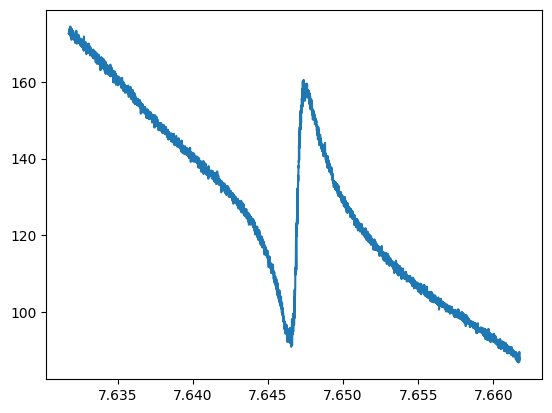

In [7]:
plt.plot(freqs, phase)

In [10]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
def lorentzian(x, x0, A, B, gamma):
    """
    x: Independent variable
    x0: Center of the peak
    A: Amplitude (maximum height)
    gamma: Half-Width at Half-Maximum (HWHM)
    """
    return A * (gamma**2) / ((x - x0)**2 + gamma**2) + B

In [11]:
p0_x0 = freqs[np.argmin(mags)]  # Find X value where Y is maximum
p0_A = -12              # Find maximum Y value
p0_B = -72
p0_gamma = 0.01                     # Initial guess for HWHM
initial_guess = [p0_x0, p0_A, p0_B, p0_gamma]
print(initial_guess)

popt, pcov = sp.optimize.curve_fit(lorentzian, freqs, mags, p0=initial_guess)

x0_opt, A_opt, B_opt, gamma_opt = popt
errors = np.sqrt(np.diag(pcov))

print(f"Match Results:")
print(f"Center (x0): {x0_opt:.3f} ± {errors[0]:.3f}")
print(f"Amplitude (A): {A_opt:.3f} ± {errors[1]:.3f}")
print(f"Baseline (B): {B_opt:.3f} ± {errors[2]:.3f}")
print(f"HWHM (gamma): {gamma_opt:.3f} ± {errors[3]:.3f}")

fit_label = f"""
Fit Lorentzian
omega_0: {x0_opt:.3e} GHz
Amplitude (A): {A_opt:.3e}
Baseline (B): {B_opt:.3e}
HWHM: {gamma_opt*1000:.3f} MHz
"""

[np.float64(7.646964849), -12, -72, 0.01]
Match Results:
Center (x0): 7.647 ± 0.000
Amplitude (A): -10.702 ± 0.061
Baseline (B): -63.852 ± 0.009
HWHM (gamma): 0.001 ± 0.000


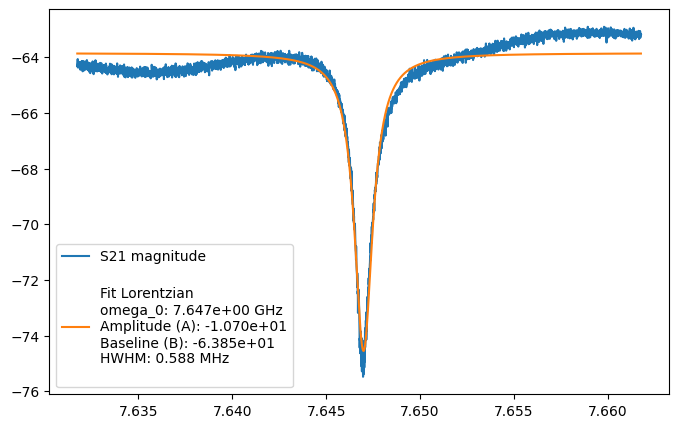

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(freqs, mags, label="S21 magnitude")
plt.plot(freqs, lorentzian(freqs, *popt), label=fit_label)
plt.legend()

## 4. Optional: Interpolate Data

Increase the number of points if needed. The CSV sweep here already has a
fine, evenly spaced grid, so this is usually unnecessary.

In [6]:
# Set this to True if you want to interpolate the data
use_interpolation = False
num_interpolation_points = 1000

if use_interpolation:
    print("Interpolating data...")

    # Create common frequency range
    common_freq = np.linspace(frequency.min(), frequency.max(), num=num_interpolation_points)

    # Interpolation functions
    amplitude_interp = interp1d(frequency, amplitude_db, kind='linear', fill_value='extrapolate')
    phase_interp = interp1d(frequency, phase_deg, kind='linear', fill_value='extrapolate')

    # Generate interpolated data
    new_amplitude_db = amplitude_interp(common_freq)
    new_phase_deg = phase_interp(common_freq)

    # Convert to complex
    new_amplitude_linear = 10 ** (new_amplitude_db / 20)
    new_phase_rad = np.deg2rad(new_phase_deg)
    new_s21_complex = new_amplitude_linear * np.exp(1j * new_phase_rad)

    # Use interpolated data for fitting
    freq_for_fit = common_freq
    s21_for_fit = new_s21_complex

    print(f"\u2713 Interpolated to {num_interpolation_points} points")
    print(f"  Data points for fitting: {len(freq_for_fit)}")
else:
    # freq_for_fit / s21_for_fit are set later by the frequency-window
    # sweep in the "Perform Circle Fit" section below.
    print(f"  Interpolation skipped. Using {len(frequency)} raw data points "
          f"(fit window selected automatically in the next section).")

  Interpolation skipped. Using 4001 raw data points (fit window selected automatically in the next section).


## 5. Perform Circle Fit with qkit

This is the main fitting step using qkit's circle fitting algorithm. The frequency window is swept automatically to find the best fit.

In [7]:
# ============================================================================
# STEP 1: Robust global delay estimate from the FULL sweep
# ============================================================================
# Each candidate window below used to re-derive cable delay from scratch,
# using only its own (sometimes narrow) slice of data. A narrow window
# doesn't leave much off-resonant baseline to pin down delay accurately,
# which shows up as a small extra loop in the complex-plane circle and
# NaN error bars (ill-conditioned covariance matrix). Fitting delay once
# from the full wide sweep - which has plenty of off-resonant points - and
# reusing that value for every window fixes this.

import inspect

port_func = reflection_port if fit_type == "reflection" else notch_port

fixed_delay = None
try:
    _delay_probe = port_func(frequency, s21_complex)
    _delay_probe.autofit()
    fixed_delay = getattr(_delay_probe, "_delay", None)
except Exception as e:
    print(f"  Could not get a global delay estimate ({e}); falling back to "
          f"per-window delay fitting.")

_autofit_params = inspect.signature(port_func.autofit).parameters
_supports_delay_kw = "electric_delay" in _autofit_params

if fixed_delay is not None and _supports_delay_kw:
    print(f"  Global delay estimate: {fixed_delay:.4e} s (from full {len(frequency)}-point sweep)")
else:
    if fixed_delay is None:
        pass  # message already printed above
    elif not _supports_delay_kw:
        print("  Note: this qkit version's autofit() doesn't accept 'electric_delay'; "
              "each window will re-estimate delay independently.")
    fixed_delay = None

# ============================================================================
# STEP 2: FREQUENCY MASK SWEEP - Find optimal fitting window
# ============================================================================
from itertools import product as iproduct

# Define sweep grid relative to the full data range
f_center_guess = frequency[np.argmin(amplitude_db)]  # rough resonance location
linewidth_guess = (frequency.max() - frequency.min()) / 10   # rough FWHM estimate

# Raised the minimum span from 2x to 4x linewidth: very narrow windows don't
# leave enough off-resonant baseline for a numerically stable circle fit and
# tend to produce singular covariance matrices (NaN uncertainties).
span_factors = np.arange(4, 16, 1)           # try 4x to 15x linewidth
center_offsets = np.linspace(-0.3, 0.3, 7)   # \u00b130% center shift

best_chi2 = np.inf
best_fmin, best_fmax = frequency.min(), frequency.max()
best_result = None

results_grid = []

for span_f, coff in iproduct(span_factors, center_offsets):
    half_span = span_f * linewidth_guess / 2
    fc = f_center_guess * (1 + coff * linewidth_guess / f_center_guess)
    fmin_try = fc - half_span
    fmax_try = fc + half_span

    mask_try = (frequency >= fmin_try) & (frequency <= fmax_try)
    if mask_try.sum() < 30:          # need enough points
        continue

    f_try = frequency[mask_try]
    s21_try = s21_complex[mask_try]

    try:
        m = port_func(f_try, s21_try)
        if fixed_delay is not None:
            m.autofit(electric_delay=fixed_delay)
        else:
            m.autofit()
        r = m.fitresults
        chi2 = r.get('chi_square', np.inf)
        Qi   = r.get('Qi_dia_corr', np.nan)
        Ql   = r.get('Ql', np.nan)
        Ql_err = r.get('Ql_err', np.nan)
        Qi_err = r.get('Qi_dia_corr_err', np.nan)

        # A fit whose own error bars come back NaN/inf is numerically
        # ill-conditioned - don't let it win just because chi2 looks low.
        errors_ok = np.isfinite(Ql_err) and np.isfinite(Qi_err)

        results_grid.append({
            'fmin': fmin_try, 'fmax': fmax_try,
            'chi2': chi2, 'Qi': Qi, 'Ql': Ql,
            'n_pts': mask_try.sum(), 'errors_ok': errors_ok
        })

        if chi2 < best_chi2 and Qi > 0 and errors_ok:
            best_chi2 = chi2
            best_fmin, best_fmax = fmin_try, fmax_try
            best_result = m
    except Exception:
        pass

mask_best = (frequency >= best_fmin) & (frequency <= best_fmax)
freq_for_fit = frequency[mask_best]
s21_for_fit = s21_complex[mask_best]

n_valid = sum(1 for r in results_grid if r['errors_ok'])
print(f"\u2713 Swept {len(results_grid)} candidate frequency windows "
      f"({n_valid} with well-conditioned error bars)")
if best_result is not None:
    print(f"  Best window: {best_fmin/1e9:.6f} - {best_fmax/1e9:.6f} GHz "
          f"({mask_best.sum()} points), chi\u00b2 = {best_chi2:.4e}")
else:
    print("  \u26a0 No window produced finite error bars \u2014 see the Tips section "
          "for what to try next (e.g. wider span_factors, more averaging).")

/home/spinoandraptos/Documents/CQT/.venv/lib/python3.12/site-packages/qkit/analysis/circle_fit/circle_fit_classic/circlefit.py:132: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x0 = spopt.fsolve(func, 0., fprime=d_func)
/home/spinoandraptos/Documents/CQT/.venv/lib/python3.12/site-packages/qkit/analysis/circle_fit/circle_fit_classic/circuit.py:295: RuntimeWarning: invalid value encountered in sqrt
  errors = np.sqrt(np.diagonal(cov))
/home/spinoandraptos/Documents/CQT/.venv/lib/python3.12/site-packages/qkit/analysis/circle_fit/circle_fit_classic/circuit.py:300: RuntimeWarning: invalid value encountered in sqrt
  Qi_no_corr_err = np.sqrt((dQl**2*cov[2][2]) + (dabsQc**2*cov[1][1])+(2*dQl*dabsQc*cov[2][1]))  #with correlations
/home/spinoandraptos/Documents/CQT/.venv/lib/python3.12/site-packages/qkit/analysis/circle_fit/circle_fit_classic/circuit.py:308: RuntimeWarning: invalid value encountered in sqrt
  Qi_dia

✓ Swept 84 candidate frequency windows (83 with well-conditioned error bars)
  Best window: 7.641265 - 7.653265 GHz (1600 points), chi² = 5.3386e-04


## 6. Extract and Display Results


Resonance Frequency (f0)            7.646940954 GHz
  =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   = 
Loaded Q (Q_L)                      3747.2
Internal Q (Q_i, dia corrected)     13329.6
Internal Q (Q_i, no correction)     13383.1
Coupling Q (Q_c, dia corrected)     5212.5
Coupling Q (|Q_c|)                  5204.3
  =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   = 
Bandwidth (FWHM)                    2.041 MHz
Bandwidth (FWHM)                    2040.731 kHz

Q Factor Relationship:              1/Q_L = 1/Q_i + 1/Q_c
Verification:                       1/Q_L = 2.668690e-04
  1/Q_i + 1/Q_c                     = 2.668690e-04
  Calculated Q_L                    = 3747.2
  Match                             ✓

ALL FIT PARAMETERS
Qi_dia_corr                    1.332960e+04
Qi_no_corr                     1.338307e+04
absQc                          5.204330e+03
Qc_dia_corr                    5.212460e+03
Ql                         

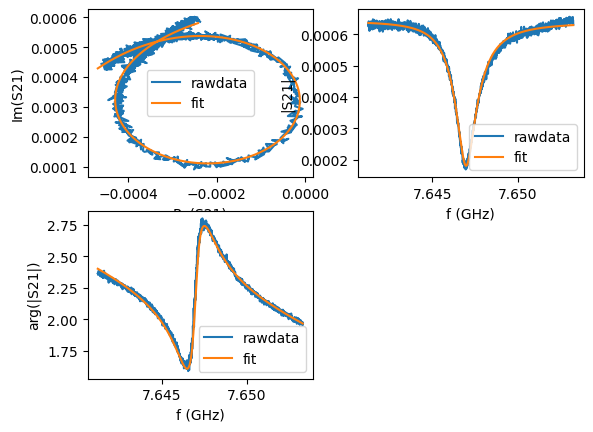

In [8]:
# Extract key results
if best_result is None:
    raise RuntimeError("No valid fit found \u2014 try widening the sweep grid in the previous cell "
                        "or double-check trace / fit_type match your resonance")
results = best_result.fitresults

# Main Q factors
f0 = results['fr']  # Resonance frequency
Q_loaded = results['Ql']  # Loaded Q
Q_internal_dia = results['Qi_dia_corr']  # Internal Q (diameter corrected)
Q_internal_no_corr = results['Qi_no_corr']  # Internal Q (no correction)
Q_coupling_dia = results['Qc_dia_corr']  # Coupling Q (diameter corrected)
Q_coupling_abs = results['absQc']  # Absolute coupling Q

# Calculate bandwidth
bandwidth = f0 / Q_loaded

# Display results
print(f"\n{'Resonance Frequency (f0)':<35} {f0/1e9:.9f} GHz")
print(f"{'  = '*20}")
print(f"{'Loaded Q (Q_L)':<35} {Q_loaded:.1f}")
print(f"{'Internal Q (Q_i, dia corrected)':<35} {Q_internal_dia:.1f}")
print(f"{'Internal Q (Q_i, no correction)':<35} {Q_internal_no_corr:.1f}")
print(f"{'Coupling Q (Q_c, dia corrected)':<35} {np.abs(Q_coupling_dia):.1f}")
print(f"{'Coupling Q (|Q_c|)':<35} {Q_coupling_abs:.1f}")
print(f"{'  = '*20}")
print(f"{'Bandwidth (FWHM)':<35} {bandwidth/1e6:.3f} MHz")
print(f"{'Bandwidth (FWHM)':<35} {bandwidth/1e3:.3f} kHz")
print(f"\n{'Q Factor Relationship:':<35} 1/Q_L = 1/Q_i + 1/Q_c")
calc_Ql = 1 / (1/Q_internal_dia + 1/np.abs(Q_coupling_dia))
print(f"{'Verification:':<35} 1/Q_L = {1/Q_loaded:.6e}")
print(f"{'  1/Q_i + 1/Q_c':<35} = {1/Q_internal_dia + 1/np.abs(Q_coupling_dia):.6e}")
print(f"{'  Calculated Q_L':<35} = {calc_Ql:.1f}")
print(f"{'  Match':<35} \u2713" if abs(calc_Ql - Q_loaded)/Q_loaded < 0.01 else f"{'  Match':<35} \u2717")

print("\n" + "="*80)
print("ALL FIT PARAMETERS")
print("="*80)
for key, value in results.items():
    if isinstance(value, (int, float, complex)):
        if isinstance(value, complex):
            print(f"{key:<30} {value.real:.6e} + {value.imag:.6e}j")
        else:
            print(f"{key:<30} {value:.6e}")
    else:
        print(f"{key:<30} {value}")
print("="*80)
best_result.plotall()

## 7. Plot Circle in Complex Plane

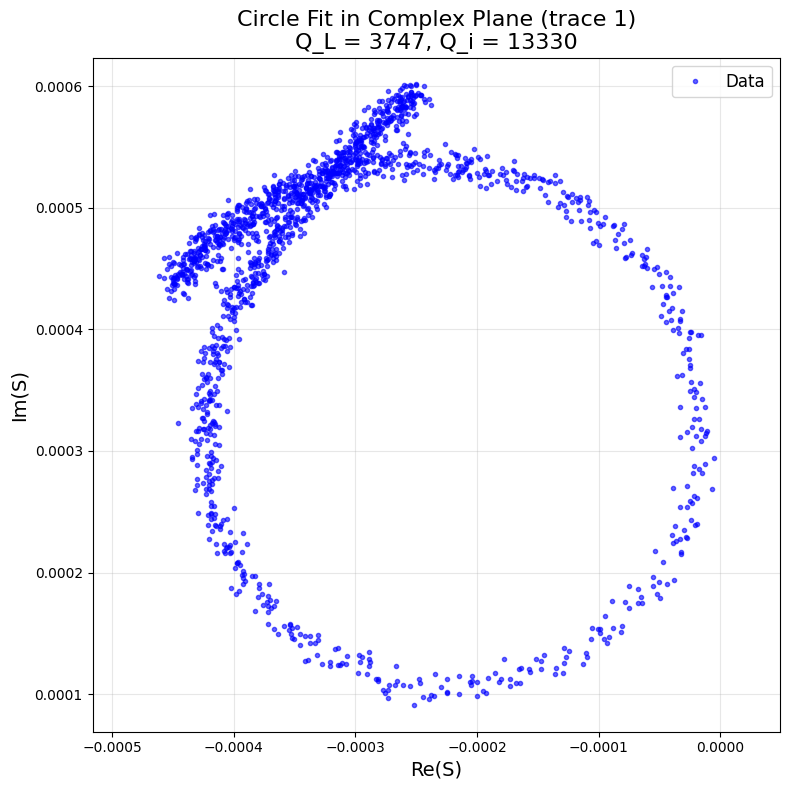

In [9]:
plt.figure(figsize=(8, 8))
plt.plot(s21_for_fit.real, s21_for_fit.imag, 'b.', markersize=6, label='Data', alpha=0.6)
plt.xlabel('Re(S)', fontsize=14)
plt.ylabel('Im(S)', fontsize=14)
plt.title(f'Circle Fit in Complex Plane (trace {trace})\nQ_L = {Q_loaded:.0f}, Q_i = {Q_internal_dia:.0f}', fontsize=16)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 8. Additional Analysis: Compare Amplitude and Phase

Verify that the fit window subset matches the original data.

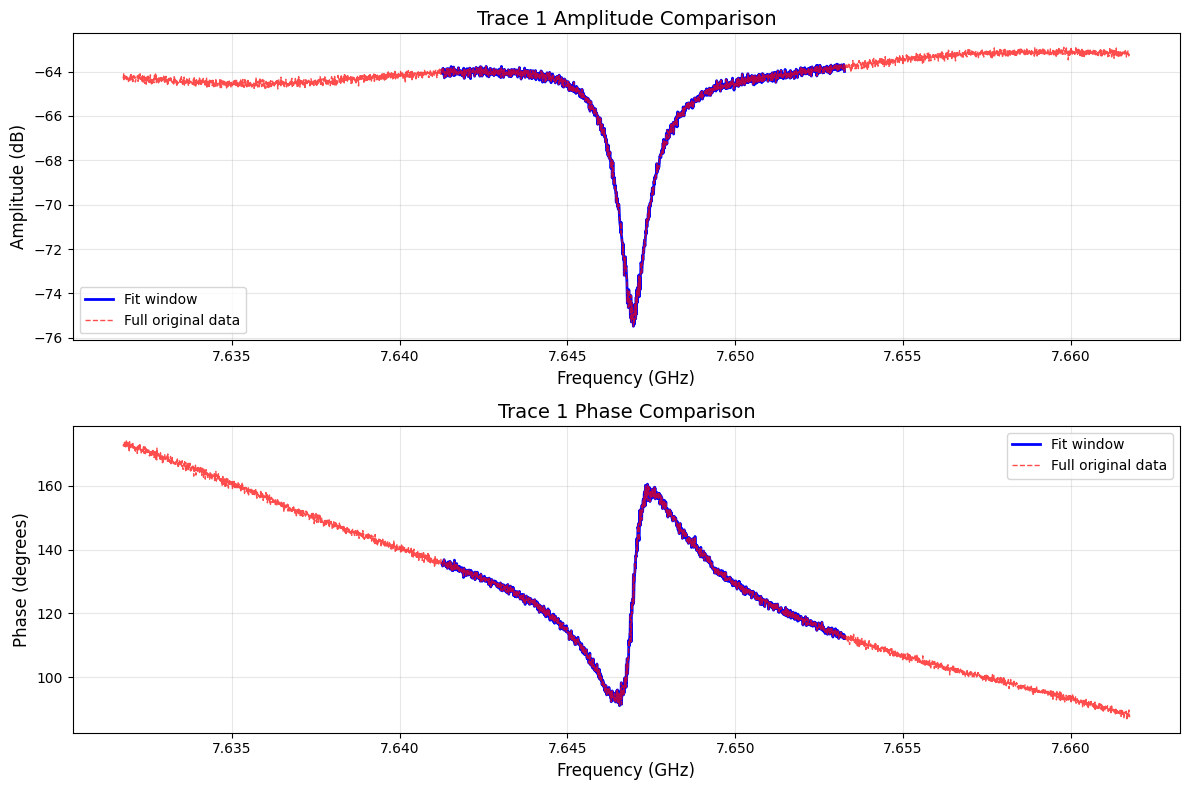

✓ Fit window verified against full dataset


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot amplitude from fit window vs full original data
axes[0].plot(freq_for_fit/1e9, 20*np.log10(np.abs(s21_for_fit)), 'b-', label='Fit window', linewidth=2)
if not use_interpolation:
    axes[0].plot(frequency/1e9, amplitude_db, 'r--', label='Full original data', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Frequency (GHz)', fontsize=12)
axes[0].set_ylabel('Amplitude (dB)', fontsize=12)
axes[0].set_title(f'Trace {trace} Amplitude Comparison', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot phase from fit window vs full original data
axes[1].plot(freq_for_fit/1e9, np.angle(s21_for_fit, deg=True), 'b-', label='Fit window', linewidth=2)
if not use_interpolation:
    axes[1].plot(frequency/1e9, phase_deg, 'r--', label='Full original data', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Frequency (GHz)', fontsize=12)
axes[1].set_ylabel('Phase (degrees)', fontsize=12)
axes[1].set_title(f'Trace {trace} Phase Comparison', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\u2713 Fit window verified against full dataset")

## 9. Sweep Diagnostics

Visualize how fit quality and extracted Q values vary with the chosen fitting window.

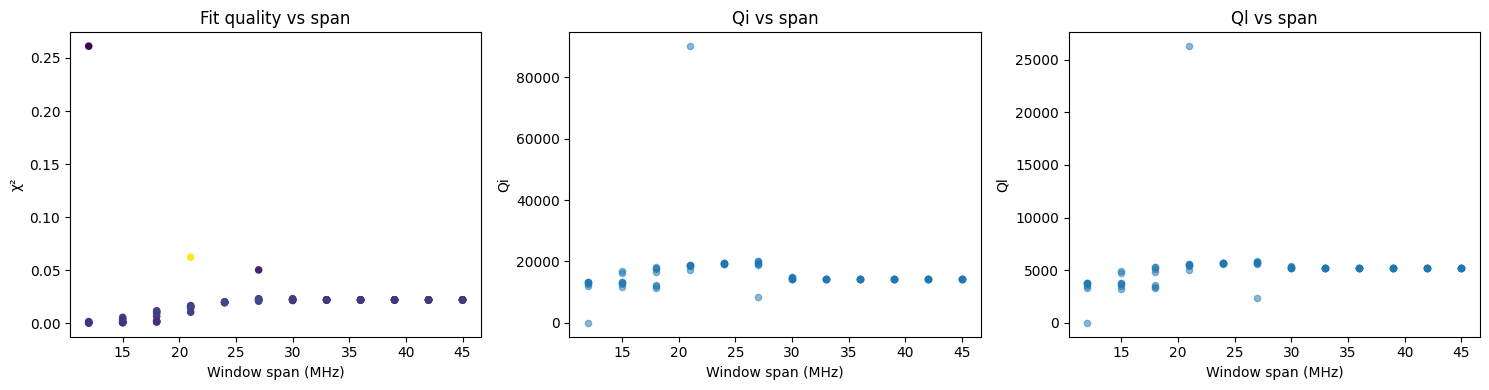

In [11]:
df = pd.DataFrame(results_grid)

# Plot chi\u00b2 as a function of window width
df['span_MHz'] = (df['fmax'] - df['fmin']) / 1e6
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(df['span_MHz'], df['chi2'], c=df['Qi'], cmap='viridis', s=20)
axes[0].set_xlabel('Window span (MHz)'); axes[0].set_ylabel('\u03c7\u00b2'); axes[0].set_title('Fit quality vs span')
axes[1].scatter(df['span_MHz'], df['Qi'], alpha=0.5, s=20)
axes[1].set_xlabel('Window span (MHz)'); axes[1].set_ylabel('Qi'); axes[1].set_title('Qi vs span')
axes[2].scatter(df['span_MHz'], df['Ql'], alpha=0.5, s=20)
axes[2].set_xlabel('Window span (MHz)'); axes[2].set_ylabel('Ql'); axes[2].set_title('Ql vs span')
plt.tight_layout(); plt.show()

## 10. Export Results to CSV

In [12]:
# Create results summary
results_summary = pd.DataFrame({
    'Parameter': [
        'Source file',
        'Trace fit',
        'Resonance Frequency (Hz)',
        'Resonance Frequency (GHz)',
        'Q_loaded',
        'Q_internal (dia corrected)',
        'Q_internal (no correction)',
        'Q_coupling (dia corrected)',
        'Q_coupling (absolute)',
        'Bandwidth (Hz)',
        'Bandwidth (MHz)',
        'Bandwidth (kHz)'
    ],
    'Value': [
        csv_filename,
        f"trace {trace}",
        f"{f0:.9f}",
        f"{f0/1e9:.9f}",
        f"{Q_loaded:.1f}",
        f"{Q_internal_dia:.1f}",
        f"{Q_internal_no_corr:.1f}",
        f"{np.abs(Q_coupling_dia):.1f}",
        f"{Q_coupling_abs:.1f}",
        f"{bandwidth:.6f}",
        f"{bandwidth/1e6:.6f}",
        f"{bandwidth/1e3:.6f}"
    ]
})

# Save results
output_filename = 'circle_fit_results.csv'
results_summary.to_csv(output_filename, index=False)
print(f"\u2713 Results saved to: {output_filename}")

# Also save the fitted data
fitted_data = pd.DataFrame({
    'Frequency (Hz)': freq_for_fit,
    'S_real': s21_for_fit.real,
    'S_imag': s21_for_fit.imag,
    'S_magnitude_dB': 20*np.log10(np.abs(s21_for_fit)),
    'S_phase_deg': np.angle(s21_for_fit, deg=True)
})

fitted_data_filename = 'fitted_data.csv'
fitted_data.to_csv(fitted_data_filename, index=False)
print(f"\u2713 Fitted data saved to: {fitted_data_filename}")

# Display summary
print("\nResults Summary:")
print(results_summary.to_string(index=False))

✓ Results saved to: circle_fit_results.csv
✓ Fitted data saved to: fitted_data.csv

Results Summary:
                 Parameter                Value
               Source file             OUT2.csv
                 Trace fit              trace 1
  Resonance Frequency (Hz) 7646940953.842890739
 Resonance Frequency (GHz)          7.646940954
                  Q_loaded               3747.2
Q_internal (dia corrected)              13329.6
Q_internal (no correction)              13383.1
Q_coupling (dia corrected)               5212.5
     Q_coupling (absolute)               5204.3
            Bandwidth (Hz)       2040731.280562
           Bandwidth (MHz)             2.040731
           Bandwidth (kHz)          2040.731281


## 11. Quick Reference: Understanding the Results

### Q Factors Explained:

1. **Q_loaded (Q_L)**
   - Total quality factor of the resonator
   - Includes all losses (internal + coupling)
   - Measured directly from the resonance linewidth
   - Formula: Q_L = f\u2080 / \u0394f

2. **Q_internal (Q_i)**
   - Internal quality factor
   - Represents losses within the resonator (material losses, surface losses, etc.)
   - Higher Q_i = better resonator material/design
   - Two versions:
     - `Qi_dia_corr`: Corrected using diameter method (more accurate)
     - `Qi_no_corr`: Without correction

3. **Q_coupling (Q_c)**
   - Coupling quality factor
   - Represents losses due to coupling to external ports
   - Related to how strongly the resonator couples to the measurement circuit
   - Two versions:
     - `Qc_dia_corr`: Diameter corrected
     - `absQc`: Absolute value

### Relationship:
$$\frac{1}{Q_L} = \frac{1}{Q_i} + \frac{1}{Q_c}$$

### Coupling Regimes:
- **Undercoupled**: Q_c > Q_i (weak coupling)
- **Critically coupled**: Q_c = Q_i (matched coupling)
- **Overcoupled**: Q_c < Q_i (strong coupling)

### Which Q to Report?
- **Q_loaded**: Overall performance of the coupled system
- **Q_internal**: Intrinsic quality of the resonator (most important for material characterization)
- Always report all three for complete characterization!

## Tips and Troubleshooting

### If the fit fails or gives unreasonable results:

1. **Check your data:**
   - Confirm the header row (`PNT,...`) was found and columns parsed as expected
   - Verify which trace/columns actually contain your resonance
   - Make sure you have enough points around the resonance (at least 50-100)

2. **Pick the right trace:**
   - `trace` / `fit_type` must match where the resonance actually shows up
   - Check the `!PARAMETER:` / `!PORT:` / `!GRAPH:` comment lines at the top
     of the CSV to see what each trace measures
   - Look at the amplitude plot in Section 3 \u2014 the resonance is the trace
     with a clear dip, not one sitting flat at the noise floor

3. **Try interpolation:**
   - Set `use_interpolation = True` if your sweep is too coarse

4. **Reflection vs Transmission:**
   - Use `notch_port()` (`fit_type = 'notch'`) for S21/S12
   - Use `reflection_port()` (`fit_type = 'reflection'`) for S11/S22

5. **Negative Q_internal:**
   - Indicates overcoupled resonator or fitting issues
   - Check if your resonator is actually overcoupled
   - Try adjusting the frequency window sweep grid in Section 5

### Data Quality Requirements:
- **Frequency span**: Cover at least 5-10 linewidths around resonance
- **Number of points**: 50-200 points for good fitting
- **SNR**: Higher signal-to-noise ratio gives better fits
- **VNA calibration**: Proper calibration is essential